Saving archive (4).zip to archive (4) (1).zip
                                                text  label
0  I grew up (b. 1965) watching and loving the Th...      0
1  When I put this movie in my DVD player, and sa...      0
2  Why do people who do not know what a particula...      0
3  Even though I have great interest in Biblical ...      0
4  Im a die hard Dads Army fan and nothing will e...      1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    40000 non-null  object
 1   label   40000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 625.1+ KB
None
text     0
label    0
dtype: int64
Accuracy Score:
0.857875

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      3966
           1       0.88      0.83      0.86      4034

    accuracy                         

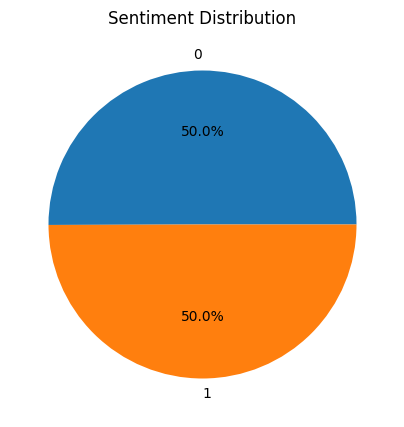


Sample Prediction:
1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from google.colab import files

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall()

df = pd.read_csv('Train.csv')

print(df.head())

print(df.info())

print(df.isnull().sum())

df.dropna(inplace=True)

x = df['text']
y = df['label']

cv = CountVectorizer(stop_words='english')

x_vectorized = cv.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

model = MultinomialNB()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy Score:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

sentiment_counts = df['label'].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Distribution")
plt.show()

sample = ["This movie was amazing and very enjoyable"]

sample_vector = cv.transform(sample)

prediction = model.predict(sample_vector)

print("\nSample Prediction:")
print(prediction[0])